In [1]:
###############   PHASE : 1 ####################

## Import Libraries
import pandas as pd
import numpy as np

In [2]:
## Load All CSV Files
back = pd.read_csv("data/Data_of_Attack_Back.csv")
buffer_overflow = pd.read_csv("data/Data_of_Attack_Back_BufferOverflow.csv")
ftpwrite = pd.read_csv("data/Data_of_Attack_Back_FTPWrite.csv")
guesspassword = pd.read_csv("data/Data_of_Attack_Back_GuessPassword.csv")
neptune = pd.read_csv("data/Data_of_Attack_Back_Neptune.csv")
nmap = pd.read_csv("data/Data_of_Attack_Back_NMap.csv")
normal = pd.read_csv("data/Data_of_Attack_Back_Normal.csv")
portsweep = pd.read_csv("data/Data_of_Attack_Back_PortSweep.csv")
rootkit = pd.read_csv("data/Data_of_Attack_Back_RootKit.csv")
satan = pd.read_csv("data/Data_of_Attack_Back_Satan.csv")
smurf = pd.read_csv("data/Data_of_Attack_Back_Smurf.csv")

In [3]:
## Verify Structure (VERY IMPORTANT)
datasets = {
    "back": back,
    "buffer_overflow": buffer_overflow,
    "ftpwrite": ftpwrite,
    "guesspassword": guesspassword,
    "neptune": neptune,
    "nmap": nmap,
    "normal": normal,
    "portsweep": portsweep,
    "rootkit": rootkit,
    "satan": satan,
    "smurf": smurf
}

for name, data in datasets.items():
    print(f"{name} shape: {data.shape}")

back shape: (968, 41)
buffer_overflow shape: (30, 41)
ftpwrite shape: (7, 41)
guesspassword shape: (53, 41)
neptune shape: (227228, 41)
nmap shape: (1554, 41)
normal shape: (576710, 41)
portsweep shape: (2964, 41)
rootkit shape: (10, 41)
satan shape: (5019, 41)
smurf shape: (3007, 41)


In [4]:

###########         DATA PREPARATION      ################

In [5]:
## Clean Column Names

for data in [back, buffer_overflow, ftpwrite, guesspassword,
             neptune, nmap, normal, portsweep,
             rootkit, satan, smurf]:
    data.columns = data.columns.str.strip()

In [6]:
## STEP: 1 
# Add attack_type Column

back["attack_type"] = "back"
buffer_overflow["attack_type"] = "buffer_overflow"
ftpwrite["attack_type"] = "ftpwrite"
guesspassword["attack_type"] = "guesspassword"
neptune["attack_type"] = "neptune"
nmap["attack_type"] = "nmap"
normal["attack_type"] = "normal"
portsweep["attack_type"] = "portsweep"
rootkit["attack_type"] = "rootkit"
satan["attack_type"] = "satan"
smurf["attack_type"] = "smurf"

In [7]:
for name, data in datasets.items():
    print(name, data.shape, "attack_type" in data.columns)

back (968, 42) True
buffer_overflow (30, 42) True
ftpwrite (7, 42) True
guesspassword (53, 42) True
neptune (227228, 42) True
nmap (1554, 42) True
normal (576710, 42) True
portsweep (2964, 42) True
rootkit (10, 42) True
satan (5019, 42) True
smurf (3007, 42) True


In [8]:
## STEP: 2 
# MERGE ALL THE DATA 

# Merge again (clean rebuild)

df = pd.concat([
    back,
    buffer_overflow,
    ftpwrite,
    guesspassword,
    neptune,
    nmap,
    normal,
    portsweep,
    rootkit,
    satan,
    smurf
], axis=0)

df.reset_index(drop=True, inplace=True)

print("After merge:", df.shape)


After merge: (817550, 83)


In [9]:
### STEP: 3

# Create label column (Normal = 0, Attack = 1)

df["label"] = df["attack_type"].apply(lambda x: 0 if x == "normal" else 1)

print("After label:", df.shape)
print(df["label"].value_counts())

After label: (817550, 84)
label
0    576710
1    240840
Name: count, dtype: int64


In [10]:
### STEP: 4 -

# Check Missing Values

## 4.1-Check Total Missing Values in Dataset

df.isnull().sum()

duration              7
protocol_type         7
service               7
flag                  7
src_bytes             7
                  ...  
0.23             817543
0.24             817543
0.25             817543
0.26             817543
label                 0
Length: 84, dtype: int64

In [11]:
## 4.2 Check If There Are Any Missing Values Overall
df.isnull().sum().sum()

np.int64(33519550)

In [12]:
## 4.3 Percentage of Missing Values (Professional Way)
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0]

duration          0.000856
protocol_type     0.000856
service           0.000856
flag              0.000856
src_bytes         0.000856
                   ...    
0.22             99.999144
0.23             99.999144
0.24             99.999144
0.25             99.999144
0.26             99.999144
Length: 82, dtype: float64

In [13]:
### STEP: 5 -
# Remove duplicates

## 5.1 Check How Many Duplicate Rows Exist
df.duplicated().sum()

np.int64(0)

In [14]:
## 5.2 Remove Duplicates (If Any)
df.drop_duplicates(inplace=True)

In [15]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (817550, 84)


In [16]:
### STEP: 6 - 
# Check Class Imbalance (Very Important)

df["label"].value_counts()


label
0    576710
1    240840
Name: count, dtype: int64

In [17]:
df["label"].value_counts(normalize=True) * 100

label
0    70.541251
1    29.458749
Name: proportion, dtype: float64

In [18]:

################    Exploratory Data Analysis (EDA)     ###############

In [19]:
## STEP: 1 Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (817550, 84)


In [20]:
## STEP: 2 Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 817550 entries, 0 to 817549
Data columns (total 84 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     817543 non-null  float64
 1   protocol_type                817543 non-null  float64
 2   service                      817543 non-null  float64
 3   flag                         817543 non-null  float64
 4   src_bytes                    817543 non-null  float64
 5   dst_bytes                    817543 non-null  float64
 6   land                         817543 non-null  float64
 7   wrong_fragment               817543 non-null  float64
 8   urgent                       817543 non-null  float64
 9   hot                          817543 non-null  float64
 10  num_failed_logins            817543 non-null  float64
 11  logged_in                    817543 non-null  float64
 12  num_compromised              817543 non-null  float64
 13  root_shell

In [21]:
## STEP: 3 Summary Statistics
df.describe()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,0.001.3,0.1.5,0.21,0.1.6,0.22,0.23,0.24,0.25,0.26,label
count,817543.000000,817543.000000,817543.000000,817543.00000,817543.000000,817543.000000,817543.0,8.175430e+05,817543.000000,817543.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.0,7.0,7.0,7.0,817550.000000
mean,0.000877,0.000570,0.052908,0.02016,0.004961,0.024862,0.0,3.669532e-07,0.000002,0.002455,...,0.025857,0.085714,0.028571,0.085714,0.013429,0.0,0.0,0.0,0.0,0.294587
std,0.026636,0.002596,0.096388,0.03096,0.033235,0.066634,0.0,3.317920e-04,0.000766,0.041469,...,0.040093,0.024398,0.048795,0.024398,0.021778,0.0,0.0,0.0,0.0,0.455857
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,...,0.001000,0.050000,0.000000,0.050000,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,...,0.001000,0.075000,0.000000,0.075000,0.000000,0.0,0.0,0.0,0.0,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.002170,0.003670,0.0,0.000000e+00,0.000000,0.000000,...,0.004000,0.100000,0.000000,0.100000,0.002000,0.0,0.0,0.0,0.0,0.000000
75%,0.000000,0.000000,0.120000,0.07000,0.002990,0.019690,0.0,0.000000e+00,0.000000,0.000000,...,0.044500,0.100000,0.050000,0.100000,0.021000,0.0,0.0,0.0,0.0,1.000000
max,1.000000,0.020000,0.670000,0.10000,1.000000,1.000000,0.0,3.000000e-01,0.500000,1.000000,...,0.085000,0.100000,0.100000,0.100000,0.050000,0.0,0.0,0.0,0.0,1.000000


In [22]:
## STEP: 4 Attack-wise Count (Multiclass View)
df["attack_type"].value_counts()

attack_type
normal             576710
neptune            227228
satan                5019
smurf                3007
portsweep            2964
nmap                 1554
back                  968
guesspassword          53
buffer_overflow        30
rootkit                10
ftpwrite                7
Name: count, dtype: int64

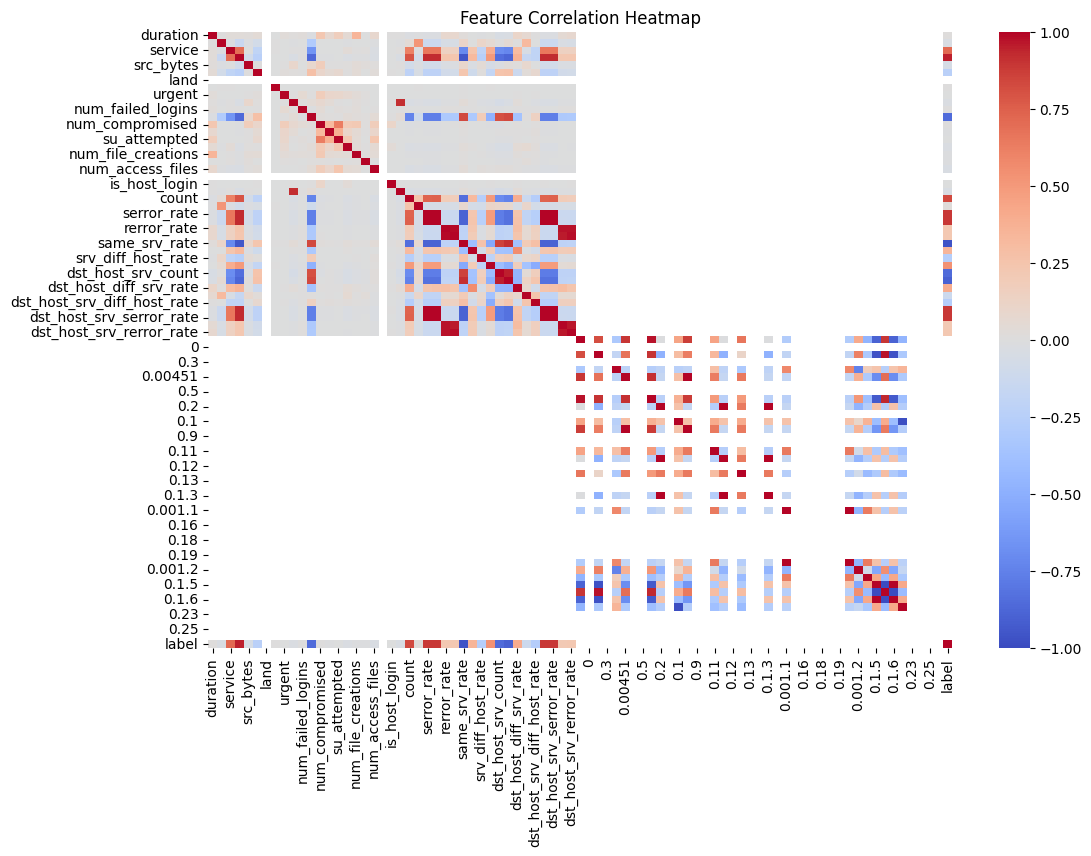

In [23]:
## STEP: 5 Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

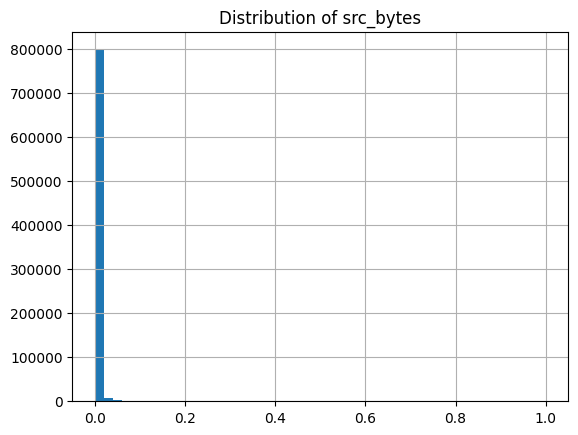

In [24]:
## STEP: 6 Distribution of Important Features
df["src_bytes"].hist(bins=50)
plt.title("Distribution of src_bytes")
plt.show()

In [25]:
############    TRAIN TEST SPLIT    ############

In [26]:
## STEP:1 Separate Features (X) and Target (y)
X = df.drop(["attack_type", "label"], axis=1)
y = df["label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (817550, 82)
Target shape: (817550,)


In [27]:
## STEP: 2  Perform Stratified 80/20 Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # VERY IMPORTANT for imbalance
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (654040, 82)
X_test shape: (163510, 82)
y_train shape: (654040,)
y_test shape: (163510,)


In [28]:
############     FEATURE ENGINEERING     #################

In [29]:
## STEP: 1 — 
# Check If Encoding Is Required

X_train.dtypes.unique()

array([dtype('float64')], dtype=object)

In [30]:
## STEP 5.2 — 

# FEATURE SCALING (StandardScaler)

from sklearn.preprocessing import StandardScaler

   # Create scaler object
scaler = StandardScaler()

   # Learn mean and std from training data
scaler.fit(X_train)

   # Transform training data
X_train_scaled = scaler.transform(X_train)

   # Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")



Scaling Completed


In [31]:
X_train_scaled.mean()

np.float64(nan)

In [32]:
X_train_scaled.std()

np.float64(nan)

In [33]:
## STEP : 3 — 
# HANDLE CLASS IMBALANCE (SMOTE)

from imblearn.over_sampling import SMOTE



In [34]:
# 3.1  Ensure no NaN or Inf values
X_train_scaled = np.nan_to_num(X_train_scaled)

In [35]:
# 3.2 Ensure y_train is 1D
y_train = y_train.values.ravel()

In [36]:
# 3.3  Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print("New Training Shape:", X_train_smote.shape)
print("Class Distribution:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
New Training Shape: (922736, 82)
Class Distribution:
1    461368
0    461368
Name: count, dtype: int64


In [37]:
## STEP : 4 -
# FINAL FEATURE SELECTION PIPELINE (Correlation-Based)

#  4.1 — Convert Scaled Arrays to DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [38]:
# 4.2 — Compute correlation matrix on training data
corr_matrix = X_train_df.corr()

In [39]:
# 4.3 — Select upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
#     — Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Number of features to drop:", len(to_drop))

Number of features to drop: 20


In [40]:
# 4.4 — Drop Those Features (Train + Test)

# Drop from training data
X_train_selected = X_train_df.drop(columns=to_drop)

# Drop same columns from test data
X_test_selected = X_test_df.drop(columns=to_drop)

print("Final Shapes After Feature Selection:")
print("X_train:", X_train_selected.shape)
print("X_test:", X_test_selected.shape)

Final Shapes After Feature Selection:
X_train: (654040, 62)
X_test: (163510, 62)


In [41]:
# 5 — Apply SMOTE on Selected Features (Again)

from imblearn.over_sampling import SMOTE

# Ensure no NaN
X_train_selected = np.nan_to_num(X_train_selected)

# Convert y_train properly
y_train = y_train.ravel()

smote = SMOTE(random_state=42)

X_train_final, y_train_final = smote.fit_resample(X_train_selected, y_train)

print("After SMOTE:")
print(pd.Series(y_train_final).value_counts())

After SMOTE:
1    461368
0    461368
Name: count, dtype: int64


In [42]:
    ##########  MODEL TRAINING  ##########

In [43]:
## STEP: 1 Import model
from sklearn.linear_model import LogisticRegression

In [44]:
## STEP: 2 Create the Model Object

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [45]:
## STEP: 3 — Train the Model
log_model.fit(X_train_final, y_train_final)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [46]:
## STEP: 4 — Make Predictions on TEST Data

# Ensure no NaN in test data
X_test_selected = np.nan_to_num(X_test_selected)

# Convert to numpy if needed
X_test_selected = np.array(X_test_selected)

# Now predict
y_pred_log = log_model.predict(X_test_selected)

print("Prediction Completed ✅")

Prediction Completed ✅


In [47]:
## STEP : 5 — Evaluate the Model

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.996483395510978

Confusion Matrix:
[[114889    453]
 [   122  48046]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    115342
           1       0.99      1.00      0.99     48168

    accuracy                           1.00    163510
   macro avg       0.99      1.00      1.00    163510
weighted avg       1.00      1.00      1.00    163510



In [48]:
## STEP : 6 — Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

# Train Decision Tree
dt_model.fit(X_train_final, y_train_final)
print("Decision Tree Training Completed ✅")


Decision Tree Training Completed ✅


In [49]:
# Make Predictions (Decision Tree)

y_pred_dt = dt_model.predict(X_test_selected)

print("Decision Tree Prediction Completed ✅")

Decision Tree Prediction Completed ✅


In [50]:
# Evaluate Decision Tree

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9997920616476057

Confusion Matrix:
[[115325     17]
 [    17  48151]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    115342
           1       1.00      1.00      1.00     48168

    accuracy                           1.00    163510
   macro avg       1.00      1.00      1.00    163510
weighted avg       1.00      1.00      1.00    163510



In [51]:
# training accuracy of Decision Tree.
print("Training Accuracy:", dt_model.score(X_train_final, y_train_final))

Training Accuracy: 0.999916552513395


In [52]:
#  RUN Evaluation again
print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Test Accuracy: 0.9997920616476057

Confusion Matrix:
[[115325     17]
 [    17  48151]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    115342
           1       1.00      1.00      1.00     48168

    accuracy                           1.00    163510
   macro avg       1.00      1.00      1.00    163510
weighted avg       1.00      1.00      1.00    163510



In [53]:
y_pred_dt = dt_model.predict(X_test_selected)

In [54]:
## STEP : 7 Train Random Forest
from sklearn.ensemble import RandomForestClassifier

In [55]:
 # Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
) 

In [56]:
# Train Random Forest
rf_model.fit(X_train_final, y_train_final)
print("Random Forest Training Completed ✅")

Random Forest Training Completed ✅


In [57]:
#Make Predictions (Random Forest)
y_pred_rf = rf_model.predict(X_test_selected)
print("Random Forest Prediction Completed ✅")

Random Forest Prediction Completed ✅


In [58]:
# Evaluate Random Forest
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Test Accuracy: 0.9996880924714084

Confusion Matrix:
[[115334      8]
 [    43  48125]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    115342
           1       1.00      1.00      1.00     48168

    accuracy                           1.00    163510
   macro avg       1.00      1.00      1.00    163510
weighted avg       1.00      1.00      1.00    163510



In [59]:
## STEP: 8  Multiclass Classification

# Create Multiclass Target Only
y_multi = df["attack_type"]

In [60]:
# Create Feature Matrix (X)
X_multi = df.drop(["label", "attack_type"], axis=1)

In [61]:
# Train-Test Split (Multiclass)
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    stratify=y_multi,
    random_state=42
)

print("Split Completed ✅")

Split Completed ✅


In [62]:
# Apply One-Hot Encoding (Multiclass)
X_train_m = pd.get_dummies(X_train_m, columns=["protocol_type", "service", "flag"])
X_test_m = pd.get_dummies(X_test_m, columns=["protocol_type", "service", "flag"])

print("Encoding Completed ✅")

Encoding Completed ✅


In [63]:
# Align Train & Test Columns
X_train_m, X_test_m = X_train_m.align(X_test_m, join='left', axis=1, fill_value=0)

print("Alignment Completed ✅")

Alignment Completed ✅


In [64]:
# Feature Scaling (Multiclass)
from sklearn.preprocessing import StandardScaler

scaler_m = StandardScaler()

# Fit only on training data
X_train_m_scaled = scaler_m.fit_transform(X_train_m)

# Transform test data
X_test_m_scaled = scaler_m.transform(X_test_m)

print("Scaling Completed ✅")

Scaling Completed ✅


In [65]:
print(y_train_m.value_counts())

attack_type
normal             461368
neptune            181782
satan                4015
smurf                2406
portsweep            2371
nmap                 1243
back                  774
guesspassword          43
buffer_overflow        24
rootkit                 8
ftpwrite                6
Name: count, dtype: int64


In [66]:
# Train Decision Tree for multiclass.

from sklearn.tree import DecisionTreeClassifier

dt_multi = DecisionTreeClassifier(
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

dt_multi.fit(X_train_m_scaled, y_train_m)

print("Multiclass Decision Tree Trained ✅")

Multiclass Decision Tree Trained ✅


In [67]:
# Predict (Multiclass)
y_pred_multi = dt_multi.predict(X_test_m_scaled)

print("Prediction Completed ✅")

Prediction Completed ✅


In [68]:
# Evaluate Multiclass Model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Test Accuracy:", accuracy_score(y_test_m, y_pred_multi))

print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_multi))

Test Accuracy: 0.9980184698183597

Classification Report:
                 precision    recall  f1-score   support

           back       1.00      0.99      0.99       194
buffer_overflow       0.44      0.67      0.53         6
       ftpwrite       1.00      1.00      1.00         1
  guesspassword       1.00      0.90      0.95        10
        neptune       1.00      1.00      1.00     45446
           nmap       0.80      0.99      0.88       311
         normal       1.00      1.00      1.00    115342
      portsweep       0.94      0.99      0.96       593
        rootkit       0.33      0.50      0.40         2
          satan       0.88      0.98      0.93      1004
          smurf       1.00      1.00      1.00       601

       accuracy                           1.00    163510
      macro avg       0.85      0.91      0.88    163510
   weighted avg       1.00      1.00      1.00    163510



In [69]:
## STEP: 9  Final Attack Detection System (Deployment Simulation)

# Save Binary Training Columns
binary_columns = X_train_df.drop(columns=to_drop).columns.tolist()

In [70]:
# Save Multiclass Training Columns
multi_columns = X_train_m.columns.tolist()

In [71]:
# Create Final Detection Function
# (Stage 1 Only)

#Stage 1 → Detect Normal vs Attack
#Stage 2 → If Attack → Predict attack type

def detect_binary(new_data_df):

    new_data = pd.get_dummies(new_data_df)
    new_data = new_data.reindex(columns=binary_columns, fill_value=0)

    # NO SCALING

    prediction = dt_model.predict(new_data)[0]

    if prediction == 0:
        return "Normal Traffic ✅"
    else:
        return "Attack Detected 🚨"

In [72]:
sample = df.drop(["label", "attack_type"], axis=1).iloc[[0]]
print(detect_binary(sample))

Attack Detected 🚨


c:\Users\dell\Desktop\Projects\Network_Anomaly\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [73]:
## Stage 2 (Attack Type Prediction)

# Add Multiclass Columns First
multi_columns = X_train_m.columns.tolist()

In [74]:
# Create Full NIDS Function (Structure Only)
def detect_full_nids(new_data_df):
    pass

In [75]:
# Add Binary Stage Inside Full Function
def detect_full_nids(new_data_df):
    
    # ----- BINARY STAGE -----
    new_data = pd.get_dummies(new_data_df)
    new_data = new_data.reindex(columns=binary_columns, fill_value=0)

    binary_prediction = dt_model.predict(new_data)[0]

    if binary_prediction == 0:
        return "Normal Traffic ✅"

In [76]:
# Add Multiclass Stage (Final Part)
def detect_full_nids(new_data_df):
    
    # ----- BINARY STAGE -----
    new_data = pd.get_dummies(new_data_df)
    new_data = new_data.reindex(columns=binary_columns, fill_value=0)

    binary_prediction = dt_model.predict(new_data)[0]

    if binary_prediction == 0:
        return "Normal Traffic ✅"
    
    # ----- MULTICLASS STAGE -----
    new_data_multi = pd.get_dummies(new_data_df)
    new_data_multi = new_data_multi.reindex(columns=multi_columns, fill_value=0)

    attack_type = dt_multi.predict(new_data_multi)[0]

    if attack_type == "normal":
        return "Attack Detected 🚨 | Type: Unknown Attack"
    
    return f"Attack Detected 🚨 | Type: {attack_type}"

In [77]:
## Test Full model
sample = df.drop(["label", "attack_type"], axis=1).iloc[[0]]

print(detect_full_nids(sample))

Attack Detected 🚨 | Type: Unknown Attack


c:\Users\dell\Desktop\Projects\Network_Anomaly\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\dell\Desktop\Projects\Network_Anomaly\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [78]:
#########    PHASE : 2 Anomaly Detection  #####################

In [79]:
## -------------------------------------------------------
# STEP: 1 - Prepare Dataset for Anomaly Detection
## -------------------------------------------------------

# 1.1  Remove label columns (unsupervised learning)
X_anomaly = df.drop(["label", "attack_type"], axis=1)
print("Initial Shape:", X_anomaly.shape)

Initial Shape: (817550, 82)


In [80]:
# 1.2  Check NaN count per column
nan_counts = X_anomaly.isna().sum()
print("\nColumns with NaN values:")
print(nan_counts[nan_counts > 0])


Columns with NaN values:
duration              7
protocol_type         7
service               7
flag                  7
src_bytes             7
                  ...  
0.22             817543
0.23             817543
0.24             817543
0.25             817543
0.26             817543
Length: 82, dtype: int64


In [81]:
# 1.3 Remove columns with too many NaN values
# (These are broken columns created during preprocessing)
X_anomaly = X_anomaly.dropna(axis=1, thresh=100)
print("\nShape after removing broken columns:", X_anomaly.shape)


Shape after removing broken columns: (817550, 41)


In [82]:
# 1.4 Fill remaining NaN values
# Small number of missing values will be replaced with 0

X_anomaly = X_anomaly.fillna(0)
print("\nFinal Shape after cleaning:", X_anomaly.shape)


Final Shape after cleaning: (817550, 41)


In [83]:
# 1.5  Confirm no NaN values remain
print("\nRemaining NaN values:", X_anomaly.isna().sum().sum())
X_anomaly.head()



Remaining NaN values: 0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,0.0,0.0,0.0,0.5454,0.08314,0.0,0.0,0.0,0.2,...,0.001,0.001,0.1,0.0,0.100,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.5454,0.08314,0.0,0.0,0.0,0.2,...,0.002,0.002,0.1,0.0,0.050,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.5454,0.08314,0.0,0.0,0.0,0.2,...,0.003,0.003,0.1,0.0,0.033,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.5454,0.08314,0.0,0.0,0.0,0.2,...,0.004,0.004,0.1,0.0,0.025,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.5454,0.08314,0.0,0.0,0.0,0.2,...,0.005,0.005,0.1,0.0,0.020,0.0,0.0,0.0,0.0,0.0


In [84]:
## -------------------------------------------------------
# STEP: 2 - Extract Normal Traffic Only for Training
## -------------------------------------------------------


# 2.1 Identify normal traffic rows
normal_index = df["label"] == 0

In [85]:
# 2.2 Extract normal traffic features
X_normal = X_anomaly[normal_index]
print("Shape of Normal Traffic Dataset:", X_normal.shape)
X_normal.head()

Shape of Normal Traffic Dataset: (576710, 41)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
229840,0.0,0.0,0.0,0.0,0.00215,0.45076,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
229841,0.0,0.0,0.0,0.0,0.00162,0.04528,0.0,0.0,0.0,0.0,...,0.001,0.001,0.1,0.0,0.100,0.0,0.0,0.0,0.0,0.0
229842,0.0,0.0,0.0,0.0,0.00236,0.01228,0.0,0.0,0.0,0.0,...,0.002,0.002,0.1,0.0,0.050,0.0,0.0,0.0,0.0,0.0
229843,0.0,0.0,0.0,0.0,0.00233,0.02032,0.0,0.0,0.0,0.0,...,0.003,0.003,0.1,0.0,0.033,0.0,0.0,0.0,0.0,0.0
229844,0.0,0.0,0.0,0.0,0.00239,0.00486,0.0,0.0,0.0,0.0,...,0.004,0.004,0.1,0.0,0.025,0.0,0.0,0.0,0.0,0.0


In [86]:
## -------------------------------------------------------
# STEP: 3 - Train Isolation Forest.
## -------------------------------------------------------

# 3.1 Import 
from sklearn.ensemble import IsolationForest

In [87]:
# 3.2 — Create the Isolation Forest model.
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

In [88]:
# 3.3 — Train Isolation Forest on Normal Traffic
iso_model.fit(X_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [89]:
## -------------------------------------------------------
# STEP: 4 - Detect anomalies in the full dataset.
## -------------------------------------------------------

# 4.1 Predict Anomalies on Full Dataset
anomaly_predictions = iso_model.predict(X_anomaly)

In [90]:
# 4.2 — Add anomaly results to dataset and analyze them.
df["anomaly_flag"] = anomaly_predictions

In [91]:
# 4.3 — Count how many anomalies were detected.
df["anomaly_flag"].value_counts()

anomaly_flag
 1    519229
-1    298321
Name: count, dtype: int64

In [92]:
## -------------------------------------------------------
# STEP: 5 - Compare anomalies with actual attacks.
## -------------------------------------------------------

# 5.1 Compare Anomalies with Actual Attacks
pd.crosstab(df["label"], df["anomaly_flag"]) 

anomaly_flag,-1,1
label,,
0,57671,519039
1,240650,190


In [93]:
# 5.2 Calculate Attack Detection Recall

# Extract values from crosstab
attacks_detected = 240650
attacks_missed = 190

# Calculate recall
recall = attacks_detected / (attacks_detected + attacks_missed)

print("Attack Detection Recall:", recall)

Attack Detection Recall: 0.9992110945025743


In [94]:
## -------------------------------------------------------
# STEP: 6 - Convert anomaly output for pipeline
## -------------------------------------------------------

# 6.1 Convert anomaly output for pipeline
df["anomaly_binary"] = df["anomaly_flag"].apply(lambda x: 1 if x == -1 else 0)

In [95]:
# 6.2 — Check anomaly detection distribution.
df["anomaly_binary"].value_counts()

anomaly_binary
0    519229
1    298321
Name: count, dtype: int64

In [96]:
## -----------------------------------------------------------
# STEP: 7 - Integrate Anomaly Detection into the NIDS pipeline
## -----------------------------------------------------------

def hybrid_nids_detection(new_data_df):

    # ==============================
    # STEP 1 — ANOMALY DETECTION
    # ==============================

    new_data_anomaly = new_data_df.reindex(columns=X_anomaly.columns, fill_value=0)

    anomaly_pred = iso_model.predict(new_data_anomaly)[0]

    # If normal according to anomaly model
    if anomaly_pred == 1:
        return "Normal Traffic ✅ (Isolation Forest)"



    # ==============================
    # STEP 2 — BINARY CLASSIFIER
    # ==============================

    new_data_binary = pd.get_dummies(new_data_df)

    new_data_binary = new_data_binary.reindex(columns=binary_columns, fill_value=0)

    binary_pred = dt_model.predict(new_data_binary)[0]

    if binary_pred == 0:
        return "Normal Traffic ✅ (Binary Classifier)"


    # ==============================
    # STEP 3 — MULTICLASS CLASSIFIER
    # ==============================

    new_data_multi = pd.get_dummies(new_data_df)

    new_data_multi = new_data_multi.reindex(columns=multi_columns, fill_value=0)

    # SCALE using multiclass scaler
    new_data_multi_scaled = scaler_m.transform(new_data_multi)

    attack_type = dt_multi.predict(new_data_multi_scaled)[0]

    return f"🚨 Attack Detected | Type: {attack_type}"

In [97]:
sample = df.drop(["label","attack_type"], axis=1).iloc[[0]]

print(hybrid_nids_detection(sample))

🚨 Attack Detected | Type: portsweep


c:\Users\dell\Desktop\Projects\Network_Anomaly\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [98]:
    #############  PHASE: 3 XGBoost Attack Classifier   ####################
 
# 3.1 Import XGBoost

import xgboost as xgb
print("XGBoost installed successfully")

XGBoost installed successfully


In [99]:
# 3.2

# Train test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBClassifier
from xgboost import XGBClassifier


In [100]:
# 3.3 - Dataset Preparation for XGBoost.

   # 1 — Define Features and Target

# Features (all columns except label)
X = df.drop("label", axis=1)

# Target variable
y = df["label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (817550, 85)
Target shape: (817550,)


In [101]:
  # 2 Encode Categorical Columns (PUT HERE)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all categorical columns
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = le.fit_transform(X[col])

print("Categorical features encoded successfully")

Categorical features encoded successfully


In [102]:
# 3  FIX (FINAL) — Convert All Features to Numeric

# Convert categorical columns automatically
X = pd.get_dummies(X)

print("All categorical columns converted to numeric")
print("New feature shape:", X.shape)

All categorical columns converted to numeric
New feature shape: (817550, 95)


In [103]:
# Remove attack type columns (data leakage)
X = X.drop(columns=[col for col in X.columns if "attack_type" in col])

print("Attack type columns removed")
print("New feature count:", X.shape)

Attack type columns removed
New feature count: (817550, 84)


In [104]:
# 3 — Train Test Split

# -------------------------------------------------#
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (654040, 84)
Testing samples: (163510, 84)


In [105]:
## STEP 4 — Train the XGBoost Attack Classifier

   # 1 Create the XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created")

XGBoost model created


In [106]:
  # 2 — Train the Model

# Train the XGBoost model

xgb_model.fit(X_train, y_train)

print("XGBoost model training completed")


XGBoost model training completed


In [107]:
##  Model Evaluation

# Predict on test data
y_pred = xgb_model.predict(X_test)

print("Predictions generated")


Predictions generated


In [108]:
# Accuracy Score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9998899149899089


In [109]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[115148      3]
 [    15  48344]]


In [110]:
# Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    115151
           1       1.00      1.00      1.00     48359

    accuracy                           1.00    163510
   macro avg       1.00      1.00      1.00    163510
weighted avg       1.00      1.00      1.00    163510



In [111]:
print(X.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_error_rate',
       'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', '0.0026', '0',
       '0.07', '0.3', '0.00116', '0.00451', '0.4', '0.5', '0.6', '0.2', '0.7',
       '0.1', '0.8', '0.9', '0.10', '0.11', '0.1.1', '0.12', '0.1.2', '0.13',
       '0.14', '0

<Figure size 1000x600 with 0 Axes>

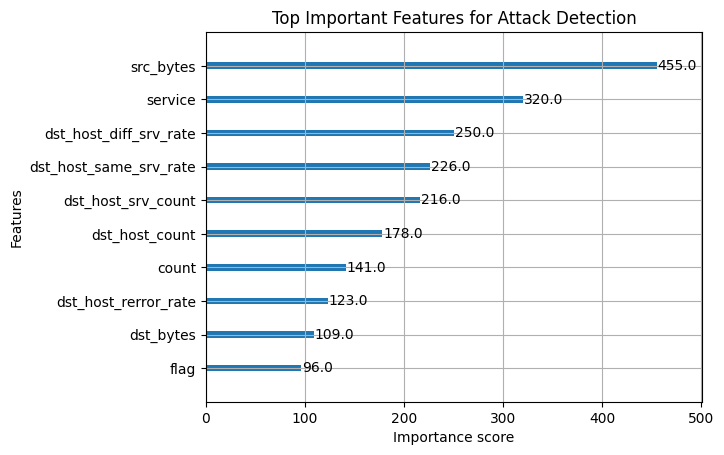

In [112]:
## (Feature Importance)

import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=10)
plt.title("Top Important Features for Attack Detection")
plt.show()

In [113]:
######   PHASE 4 — NIDS Detection Pipeline Integration    #####

# Combine Isolation Forest
# XGBoost
# Multiclass classifier
# into one real-time detection pipeline

In [127]:
# STEP : 1 — Create NIDS Detection Function 

def nids_detection(sample):

    # Ensure sample has same columns as training data
    sample_iso = sample.reindex(columns=X_normal.columns, fill_value=0)

    # STEP 1 — Isolation Forest
    anomaly_result = iso_model.predict(sample_iso)

    if anomaly_result[0] == -1:
        return "⚠️ Unknown Anomaly Detected"

    # STEP 2 — Binary attack detection
    attack_result = xgb_model.predict(sample)

    if attack_result[0] == 0:
        return "✅ Normal Traffic"

    # STEP 3 — Multiclass attack classification
    attack_type = dt_multi.predict(sample)

    return f"🚨 Attack Detected: {attack_type[0]}"


In [128]:
## STEP: 2 Prepare Input Traffic for the NIDS Pipeline

# Select one sample from test data to simulate incoming traffic

sample_traffic = X_test.iloc[[0]]
print("Sample traffic shape:", sample_traffic.shape)
sample_traffic.head()

Sample traffic shape: (1, 84)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,0.1.5,0.21,0.1.6,0.22,0.23,0.24,0.25,0.26,anomaly_flag,anomaly_binary
529029,0.0026,0.0,0.01,0.0,0.01257,0.00328,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


In [129]:
## STEP 3 Run the NIDS Detection Pipeline

# Run the NIDS detection pipeline on sample traffic

result = nids_detection(sample_traffic)
print("NIDS Detection Result:")
print(result)

NIDS Detection Result:
✅ Normal Traffic


In [130]:
## STEP 4 — Simulate Multiple Packets

# Simulate monitoring multiple network packets

for i in range(10):

    sample_packet = X_test.iloc[[i]]
    result = nids_detection(sample_packet)
    print(f"Packet {i+1} → {result}")

Packet 1 → ✅ Normal Traffic
Packet 2 → ✅ Normal Traffic
Packet 3 → ⚠️ Unknown Anomaly Detected
Packet 4 → ✅ Normal Traffic
Packet 5 → ⚠️ Unknown Anomaly Detected
Packet 6 → ✅ Normal Traffic
Packet 7 → ✅ Normal Traffic
Packet 8 → ✅ Normal Traffic
Packet 9 → ✅ Normal Traffic
Packet 10 → ✅ Normal Traffic


In [131]:
## STEP 5 — Evaluate Full NIDS System

results = []

for i in range(100):
    sample_packet = X_test.iloc[[i]]
    result = nids_detection(sample_packet)
    results.append(result)
for r in results[:20]:
    print(r)

✅ Normal Traffic
✅ Normal Traffic
⚠️ Unknown Anomaly Detected
✅ Normal Traffic
⚠️ Unknown Anomaly Detected
✅ Normal Traffic
✅ Normal Traffic
✅ Normal Traffic
✅ Normal Traffic
✅ Normal Traffic
⚠️ Unknown Anomaly Detected
✅ Normal Traffic
✅ Normal Traffic
✅ Normal Traffic
✅ Normal Traffic
⚠️ Unknown Anomaly Detected
⚠️ Unknown Anomaly Detected
⚠️ Unknown Anomaly Detected
✅ Normal Traffic
✅ Normal Traffic


In [132]:
## STEP 6 — Save Your Models

import joblib
joblib.dump(xgb_model, "xgboost_model.pkl")
joblib.dump(iso_model, "isolation_forest.pkl")
joblib.dump(dt_multi, "multiclass_model.pkl")

['multiclass_model.pkl']